In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from functions_ import carbonation_profile, carbonation_depth_at_time, state_limit_function_time

In [6]:
model = joblib.load("model_NeuralNetwork_MLP_fold_4.pkl")

In [7]:
# year = 2024
years = np.arange(0,151)
fc = 30            # MPa
rh = 70            # %
cement_type = 3
exposure = 2
co2 = 0.042

In [8]:
profile = carbonation_profile(model=model, start_year=2024, lifetime=100, fc=30, rh=70, cement_type=3, exposure=2)
profile.head() # Display the first few rows of the carbonation profile DataFrame

,calendar year,t (years),CO2 (%),carbonation depth (mm)
0,2024,0,0.042377,0.077555
1,2025,1,0.042650,1.567164
2,2026,2,0.042927,3.077445
3,2027,3,0.043207,4.503483
4,2028,4,0.043491,5.111260


In [9]:
t_query = 2050 # years

carb_depth = carbonation_depth_at_time(profile, t_query) # mm

print("Carbonation depth:", carb_depth, "mm")

Carbonation depth: 14.1186286155702 mm


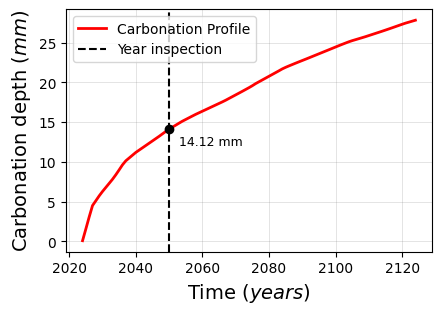

In [10]:
# Figure name and DPI
dpi = 600
name = 'carbonation_profile'

# Chart dimensions (in centimeters)
b_cm = 12
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

# Axis and labels 
label_x = 'Time ($years$)'
label_y = 'Carbonation depth ($mm$)'
size_label = 14
color_label = 'black'
size_axis = 10
color_axis = 'black'

# Line
size_line = 2
style_line = '-'
color_line = 'red'

# Marker
marker = None
size_marker = 4
color_marker = 'black'
color_marker_edge = color_line

# Legend
labels_legend = 'Carbonation Profile'
size_legend = 10
location_legend = 'upper left'

# Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

# Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

# Grid
plt.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid,
         color=color_grid, alpha=alpha_grid)

### Plot carbonation profile
ax.plot(
    profile['calendar year'],
    profile['carbonation depth (mm)'],
    markerfacecolor=color_marker,
    marker=marker,
    markersize=size_marker,
    linewidth=size_line,
    linestyle=style_line,
    color=color_line,
    label=labels_legend
)

### Linha do cobrimento
ax.axvline(
    t_query,
    linestyle='--',
    linewidth=1.5,
    color='black',
    label='Year inspection'
)

ax.scatter(
    t_query,
    carb_depth,
    color='black',
    zorder=5
)

# texto com valor da profundidade
ax.text(
    t_query + 3,        # desloca para a esquerda
    carb_depth - 2,        # desloca para baixo
    f'{carb_depth:.2f} mm',
    fontsize=9
)

# Legend
ax.legend(fontsize=size_legend, loc=location_legend)

# Save
#fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')

plt.show()